# Regression Model For Respiratory Disease Deaths

In [19]:
import pandas as pd
import matplotlib.pyplot  as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant
import statsmodels.formula.api as smf
import numpy as np
from itertools import combinations
from tqdm.notebook import tqdm
from sklearn import metrics
from statsmodels.tsa.stattools import acf

# Load the cleaned dataset
df = pd.read_csv("./datasets/processed_dataset.csv")
df.columns = df.columns.str.replace(" ", "_")
df["State"] = df["State"].astype('category')
df["County"] = df["County"].astype('category')

# Preview the data
df.head()

,State,County,Year,Days_with_AQI,Good_Days,Moderate_Days,Unhealthy_for_Sensitive_Groups_Days,Unhealthy_Days,Very_Unhealthy_Days,Hazardous_Days,...,Median_AQI,Days_CO,Days_NO2,Days_Ozone,Days_PM2.5,Days_PM10,Deaths,Population,Crude_Rate,Cause
0,Alabama,Baldwin,2018,270,232,38,0,0,0,0,...,37,0,0,194,76,0,225.0,218022.0,103.2,respiratory_diseases
1,Alabama,Clay,2018,110,86,24,0,0,0,0,...,36,0,0,0,110,0,24.0,13275.0,180.8,respiratory_diseases
2,Alabama,Colbert,2018,277,235,42,0,0,0,0,...,37,0,0,184,93,0,97.0,54762.0,177.1,respiratory_diseases
3,Alabama,DeKalb,2018,350,302,48,0,0,0,0,...,36,0,0,286,64,0,111.0,71385.0,155.5,respiratory_diseases
4,Alabama,Elmore,2018,222,203,19,0,0,0,0,...,33,0,0,222,0,0,93.0,81887.0,113.6,respiratory_diseases


In [20]:
# Check the variables
df.dtypes

State                                  category
County                                 category
Year                                      int64
Days_with_AQI                             int64
Good_Days                                 int64
Moderate_Days                             int64
Unhealthy_for_Sensitive_Groups_Days       int64
Unhealthy_Days                            int64
Very_Unhealthy_Days                       int64
Hazardous_Days                            int64
Max_AQI                                   int64
90th_Percentile_AQI                       int64
Median_AQI                                int64
Days_CO                                   int64
Days_NO2                                  int64
Days_Ozone                                int64
Days_PM2.5                                int64
Days_PM10                                 int64
Deaths                                  float64
Population                              float64
Crude_Rate                              

## Dataset Analysis

In [21]:
df.describe()

,Year,Days_with_AQI,Good_Days,Moderate_Days,Unhealthy_for_Sensitive_Groups_Days,Unhealthy_Days,Very_Unhealthy_Days,Hazardous_Days,Max_AQI,90th_Percentile_AQI,Median_AQI,Days_CO,Days_NO2,Days_Ozone,Days_PM2.5,Days_PM10,Deaths,Population,Crude_Rate
count,6198.000000,6198.000000,6198.000000,6198.000000,6198.000000,6198.000000,6198.000000,6198.000000,6198.000000,6198.000000,6198.000000,6198.000000,6198.000000,6198.000000,6198.000000,6198.000000,6198.000000,6.174000e+03,6174.000000
mean,2020.977412,329.594385,237.126008,87.907067,3.461439,0.845434,0.182156,0.072281,129.635528,60.445466,40.344789,0.178767,3.088416,161.974992,154.766538,9.585673,211.740239,2.909888e+05,100.254049
std,2.003581,67.710547,70.661562,63.380046,8.670397,3.618349,1.601665,0.706093,143.063217,15.279564,9.668227,5.172511,20.844846,114.364321,123.466126,43.834727,338.232477,5.832741e+05,40.316302
min,2018.000000,7.000000,4.000000,0.000000,0.000000,0.000000,0.000000,0.000000,14.000000,7.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,10.000000,4.074000e+03,20.500000
25%,2019.000000,342.000000,199.000000,32.000000,0.000000,0.000000,0.000000,0.000000,87.000000,52.000000,36.000000,0.000000,0.000000,75.000000,5.000000,0.000000,48.000000,4.338825e+04,69.900000
50%,2021.000000,363.000000,239.000000,79.000000,1.000000,0.000000,0.000000,0.000000,106.000000,59.000000,41.000000,0.000000,0.000000,161.000000,162.000000,0.000000,109.000000,1.142910e+05,94.600000
75%,2023.000000,365.000000,290.000000,132.000000,3.000000,0.000000,0.000000,0.000000,142.000000,66.000000,45.000000,0.000000,0.000000,243.000000,251.000000,0.000000,238.000000,2.979085e+05,124.300000
max,2024.000000,366.000000,365.000000,302.000000,109.000000,69.000000,75.000000,31.000000,8368.000000,216.000000,122.000000,259.000000,365.000000,366.000000,366.000000,366.000000,5887.000000,1.010552e+07,305.400000


### Remove Columns
We can remove the `Cause` columns since all rows contain death info related to respiratory diseases as that is the focus of our project. We can also remove `Days with AQI` since the column is the sum of the different day counts meaning we have perfect multicollinearity.

In [22]:
df = df.drop(columns=["Cause", "Days_with_AQI"])

### Transform Targets
Based on the column statistics above, we can see significant right skew for `Deaths` based on difference between mean and median. `Crude Rate` also shows some skew but it is less severe. We can log transform both target variables to help address the skew since having skew in our targets can skew the residuals violating the assumptions of the linear regression model.

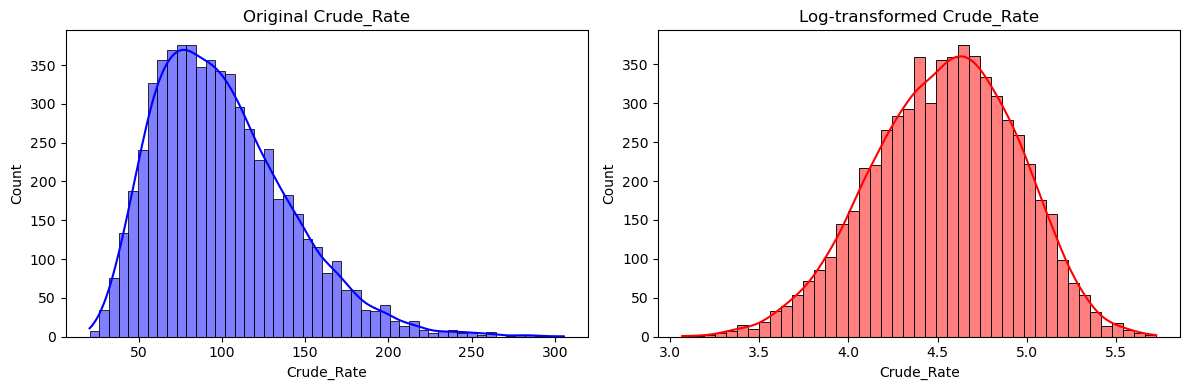

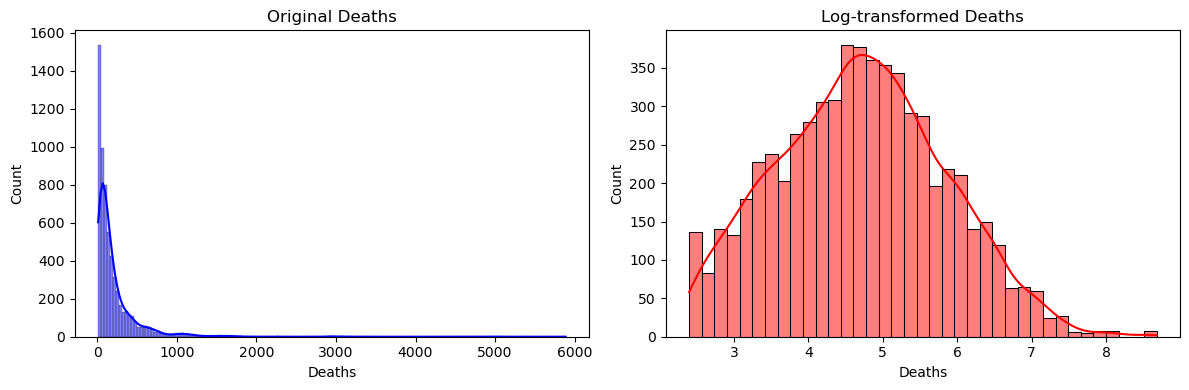

In [23]:
targets = ["Crude_Rate", "Deaths"]

for col in targets:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    
    # Original distribution
    sns.histplot(df[col], kde=True, ax=axes[0], color='blue')
    axes[0].set_title(f"Original {col}")
    
    # Log transform
    df[col] = np.log1p(df[col])

    # Log transformed distribution
    sns.histplot(df[col], kde=True, ax=axes[1], color='red')
    axes[1].set_title(f"Log-transformed {col}")
    
    plt.tight_layout()
    plt.show()

### Transform Features
Based on the column stats we can see that `Max AQI` and `Population` demonstrate significant right skew so we can also apply a log transformation to limit the effect of extreme values.

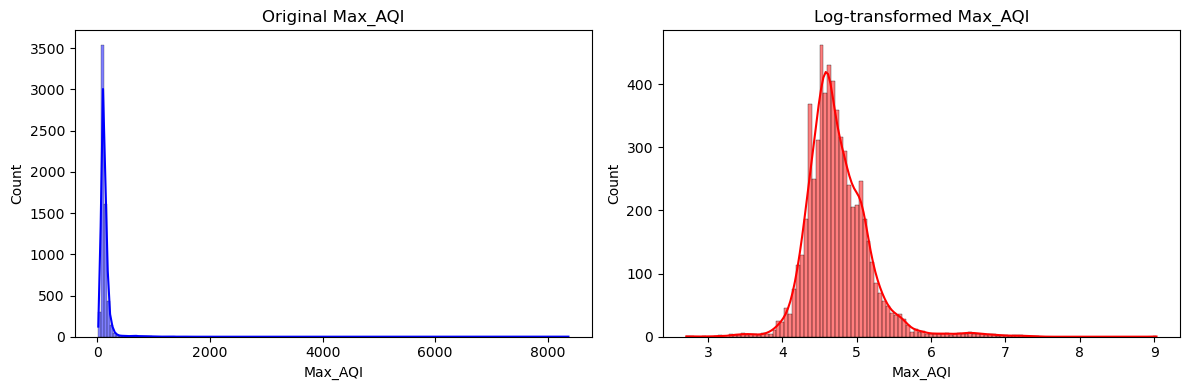

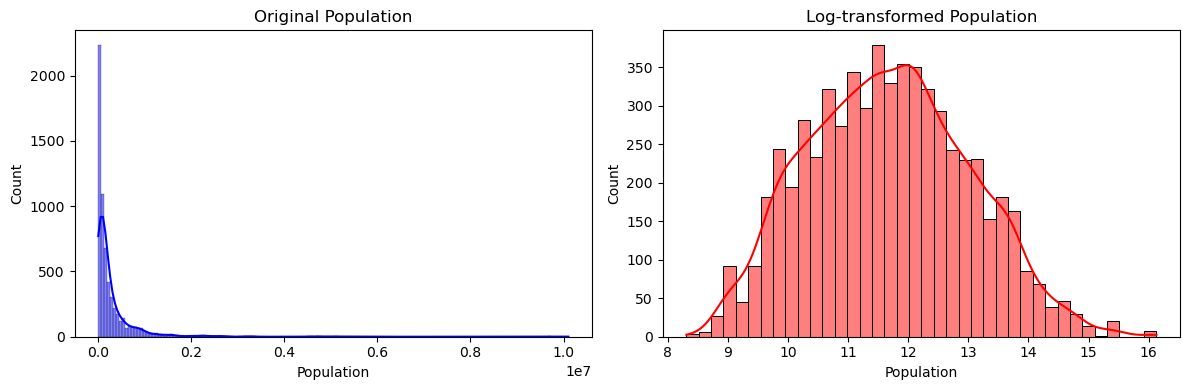

In [24]:
covariates = ["Max_AQI", "Population"]

for col in covariates:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    
    # Original distribution
    sns.histplot(df[col], kde=True, ax=axes[0], color='blue')
    axes[0].set_title(f"Original {col}")
    
    # Log transform
    df[col] = np.log1p(df[col])

    # Log transformed distribution
    sns.histplot(df[col], kde=True, ax=axes[1], color='red')
    axes[1].set_title(f"Log-transformed {col}")
    
    plt.tight_layout()
    plt.show()

Based on the column stats, there appears to be significant zero inflation meaning that many of the values are 0. If we look at `Unhealthy Days`, `Very Unhealthy Days`, `Hazardous Days`, `Days CO`, `Days NO2`, and `Days PM10` they have a 75% value of 0 indicating significant zero inflation. This indicates that the events these covariates are counting are relatively rare in many places, so it would be good to add a binary value for each covariate to allow the model to have intercept shift for places that don't experience these rare events. The model can more easily handle the difference between these events never occuring or rarely occurring.

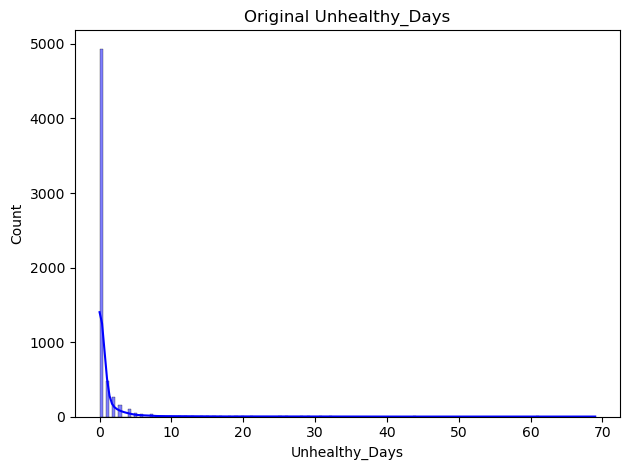

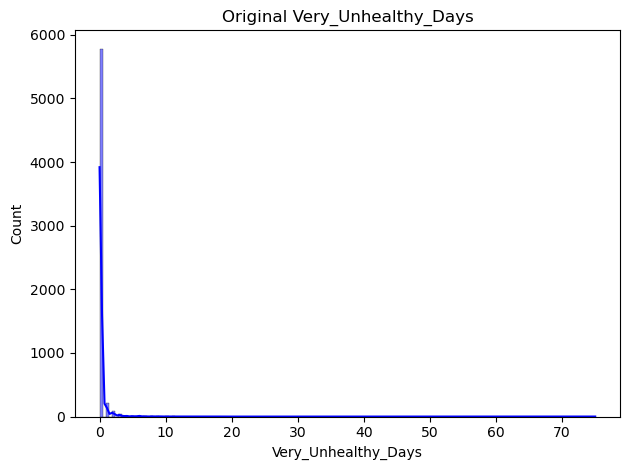

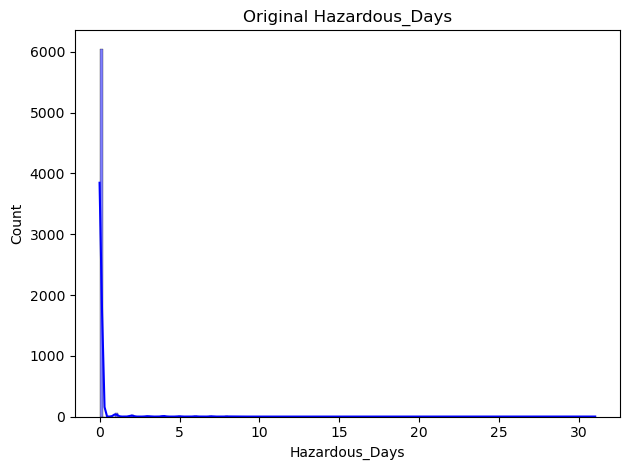

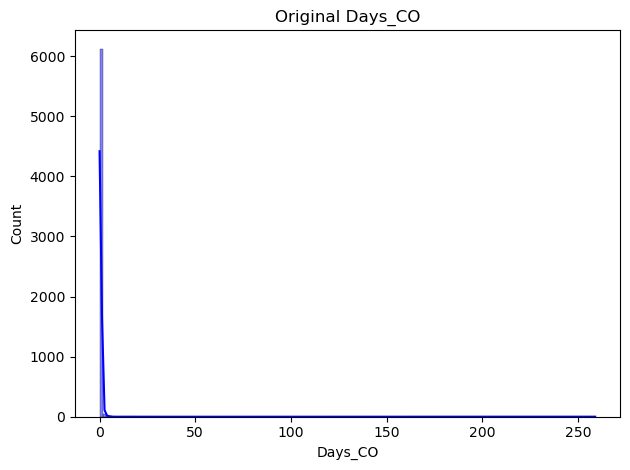

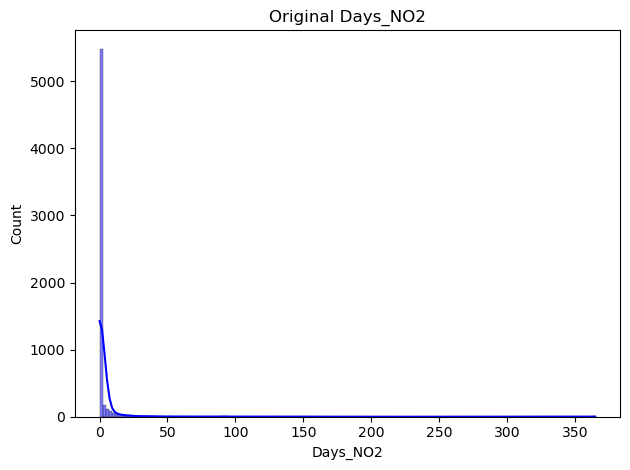

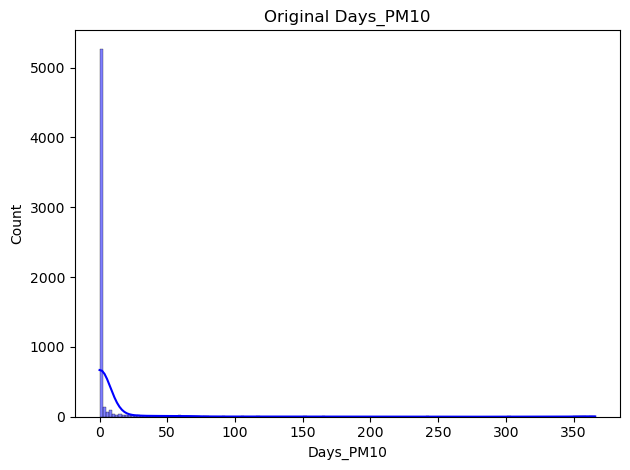

In [25]:
zero_inflated_covariates = ['Unhealthy_Days', 'Very_Unhealthy_Days', 'Hazardous_Days', 'Days_CO', 'Days_NO2', 'Days_PM10']

for col in zero_inflated_covariates:    
    sns.histplot(df[col], kde=True, color='blue')
    plt.title(f"Original {col}")
    
    plt.tight_layout()
    plt.show()

In [26]:
# Add binary terms
for col in zero_inflated_covariates:
    df[f'{col}_binary'] = (df[col] > 0).astype(int)
df.head()

,State,County,Year,Good_Days,Moderate_Days,Unhealthy_for_Sensitive_Groups_Days,Unhealthy_Days,Very_Unhealthy_Days,Hazardous_Days,Max_AQI,...,Days_PM10,Deaths,Population,Crude_Rate,Unhealthy_Days_binary,Very_Unhealthy_Days_binary,Hazardous_Days_binary,Days_CO_binary,Days_NO2_binary,Days_PM10_binary
0,Alabama,Baldwin,2018,232,38,0,0,0,0,4.584967,...,0,5.420535,12.292356,4.646312,0,0,0,0,0,0
1,Alabama,Clay,2018,86,24,0,0,0,0,4.234107,...,0,3.218876,9.493713,5.202907,0,0,0,0,0,0
2,Alabama,Colbert,2018,235,42,0,0,0,0,4.543295,...,0,4.584967,10.910770,5.182345,0,0,0,0,0,0
3,Alabama,DeKalb,2018,302,48,0,0,0,0,4.442651,...,0,4.718499,11.175857,5.053056,0,0,0,0,0,0
4,Alabama,Elmore,2018,203,19,0,0,0,0,4.276666,...,0,4.543295,11.313108,4.741448,0,0,0,0,0,0


### Correlation analysis

In this part we performed correlation analysis on the numeric predictors. Categorical vairables such as `County` and `State` will be excluded.

In [27]:
corr_df = df.drop(columns=["County", "State", "Deaths", "Crude_Rate"]).dropna()
corr_matrix = corr_df.corr(numeric_only=True)

#### Correlation Matrix

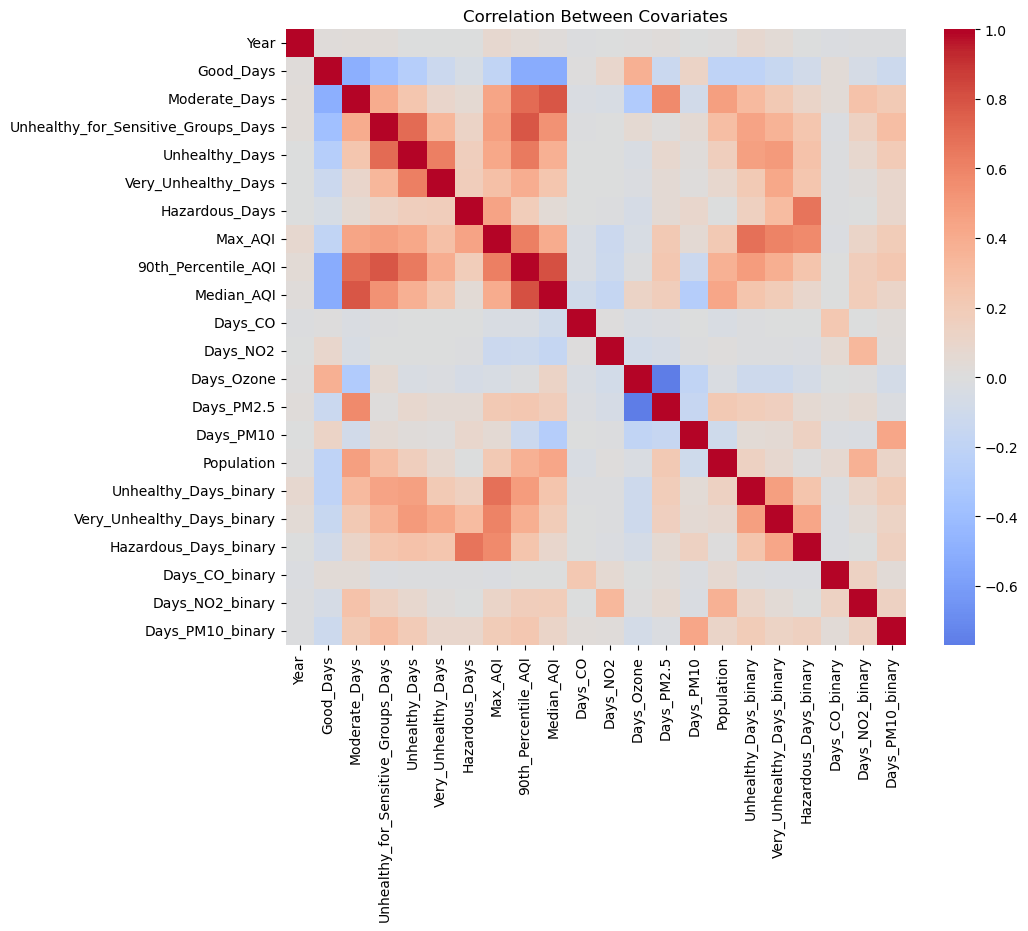

In [28]:
# Heatmap Visualization
plt.figure(figsize=(10,8))
sns.heatmap(
    corr_matrix,
    cmap="coolwarm",
    center=0
)
plt.title("Correlation Between Covariates")
plt.show()    

The heatmap visualizes the strength and direction of correlations among the numeric variables. Warmer colors(red) suggests positive correlation, while cooler colors(blue) represent negative correlations. 

From this heatmap, we observe several strong positive correlations between the AQI-related variables including Median AQI, 90th Percentile AQI, Max AQI, and the number of Moderate, Unhealthy, and Very Unhealthy Days. This is expected because they measure similar aspects of air pollution severity.  

At the same time, the variable Good Days appears to have negative correlations with many of the pollution indicators. This makes sense because counties that experience more days with good air quality generally have fewer days with higher pollution levels.

Based on this heatmap, we have evidence of multicollinearity and should drop columns with high correlation before fitting the regression model.

#### Variance Inflation Factor

In [29]:
def calc_vifs(df):
    df_const = add_constant(df)
    vif = pd.DataFrame()
    vif["variable"] = df_const.columns
    vif["VIF"] = [variance_inflation_factor(df_const.values, i) 
                  for i in range(df_const.shape[1])]
    return vif.set_index("variable").drop("const")

In [30]:
calc_vifs(corr_df)

/opt/miniconda3/envs/personal/lib/python3.11/site-packages/statsmodels/stats/outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


,VIF
variable,
Year,1.015784
Good_Days,inf
Moderate_Days,inf
Unhealthy_for_Sensitive_Groups_Days,inf
Unhealthy_Days,inf
Very_Unhealthy_Days,inf
Hazardous_Days,inf
Max_AQI,4.539715
90th_Percentile_AQI,9.191586


If we look at the VIF values, most of them appear to be really high with inf values indicating severe multicollinarity as suggested by the covariance matrix. We can remove inf values one by one where we chose to remove the inf value with the lowest correlation to our target values.

In [31]:
remaining = corr_df.columns.tolist()
iteration = 1

while True:
    vif_df = calc_vifs(df[remaining].dropna()).sort_values("VIF", ascending=False)
    print(f"\nIteration {iteration}")
    print(vif_df.round(2).to_string())

    has_inf  = np.isinf(vif_df["VIF"]).any()
    max_vif  = vif_df["VIF"].replace(np.inf, np.nan).max()

    if not has_inf and max_vif < 5:
        print("\nDone.")
        break

    if has_inf:
        inf_vars = vif_df[np.isinf(vif_df["VIF"])].index.tolist()
        target_corrs = {v: abs(df[v].corr(df['Deaths'])) for v in inf_vars}
        worst = min(target_corrs, key=target_corrs.get)
    else:
        worst = vif_df["VIF"].idxmax()

    print(f"\nDropping: '{worst}'")
    remaining.remove(worst)
    iteration += 1

/opt/miniconda3/envs/personal/lib/python3.11/site-packages/statsmodels/stats/outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)



Iteration 1
                                      VIF
variable                                 
Days_NO2                              inf
Days_Ozone                            inf
Moderate_Days                         inf
Unhealthy_for_Sensitive_Groups_Days   inf
Unhealthy_Days                        inf
Very_Unhealthy_Days                   inf
Hazardous_Days                        inf
Days_PM10                             inf
Days_PM2.5                            inf
Days_CO                               inf
Good_Days                             inf
90th_Percentile_AQI                  9.19
Median_AQI                           7.35
Max_AQI                              4.54
Hazardous_Days_binary                2.40
Unhealthy_Days_binary                2.38
Very_Unhealthy_Days_binary           1.94
Population                           1.47
Days_PM10_binary                     1.45
Days_NO2_binary                      1.39
Days_CO_binary                       1.08
Year                 

With the reduced set of covariates, we can see that we now have a set of covariates with a resonable VIF value.

In [32]:
calc_vifs(df[remaining].dropna())

,VIF
variable,
Year,1.014844
Good_Days,1.750816
Moderate_Days,2.238821
Unhealthy_for_Sensitive_Groups_Days,2.910105
Unhealthy_Days,3.364452
Very_Unhealthy_Days,1.804632
Hazardous_Days,1.854376
Max_AQI,3.905834
Days_CO,1.061236


After removing variables with high multicollinearity, the remaining covariates represent different aspects of air quality conditions and demographic factors. Variables such as Moderate_Days, Unhealthy_Days, Very_Unhealthy_Days, Hazardous_Days, and Max_AQI describe the severity of air pollution across counties. 

Additional variables including Days_CO, Days_Ozone, and Days_PM10 capture pollution from specific pollutants. Binary indicators (e.g., Unhealthy_Days_binary, Very_Unhealthy_Days_binary, Days_NO2_binary) indicate whether these pollution events occurred at least once in a given year. Finally, Population controls for differences in county size and Year accounts for overall time trends.

## Fitting Regression Model

### Processed Dataset
Split the dataset into a train set and test set for evaluating the model later

In [33]:
in_features = remaining
df = df[in_features + ["Deaths","Crude_Rate"]].dropna()
df.head()

,Year,Good_Days,Moderate_Days,Unhealthy_for_Sensitive_Groups_Days,Unhealthy_Days,Very_Unhealthy_Days,Hazardous_Days,Max_AQI,Days_CO,Days_Ozone,Days_PM10,Population,Unhealthy_Days_binary,Very_Unhealthy_Days_binary,Hazardous_Days_binary,Days_CO_binary,Days_NO2_binary,Days_PM10_binary,Deaths,Crude_Rate
0,2018,232,38,0,0,0,0,4.584967,0,194,0,12.292356,0,0,0,0,0,0,5.420535,4.646312
1,2018,86,24,0,0,0,0,4.234107,0,0,0,9.493713,0,0,0,0,0,0,3.218876,5.202907
2,2018,235,42,0,0,0,0,4.543295,0,184,0,10.910770,0,0,0,0,0,0,4.584967,5.182345
3,2018,302,48,0,0,0,0,4.442651,0,286,0,11.175857,0,0,0,0,0,0,4.718499,5.053056
4,2018,203,19,0,0,0,0,4.276666,0,222,0,11.313108,0,0,0,0,0,0,4.543295,4.741448


In [34]:
def split_data_by_year(group_df, train_frac=0.8, random_state=42):
    train_set = group_df.sample(frac=train_frac, random_state=random_state)
    test_set = group_df.drop(train_set.index)
    return train_set, test_set

train_list = []
test_list = []

for year, group_df in df.groupby('Year'):
    train_subset, test_subset = split_data_by_year(group_df, train_frac=0.8, random_state=42)
    train_list.append(train_subset)
    test_list.append(test_subset)

train_df = pd.concat(train_list)
test_df = pd.concat(test_list)

print(f"Train Set Size: {len(train_df)}")
print(f"Test Set Size: {len(test_df)}")

Train Set Size: 4939
Test Set Size: 1235


In [35]:
def generate_formulas(response, input_variables):
    formulas = []
    for k in range(1, len(in_features) + 1):
        for combo in combinations(input_variables, k):
            formula = response + "~" + " + ".join(combo)
            formulas.append(formula)
    return formulas

def find_best_bic(formulas):
    best_bic = np.inf
    best_formula = None 
    for formula in tqdm(formulas):
        model = smf.ols(formula=formula, data=train_df).fit()
        if model.bic < best_bic:
            best_bic = model.bic
            best_formula = formula
    return best_formula

### Mutliple Linear Regeression Model For Deaths

##### BIC Model Selection

In [36]:
formulas = generate_formulas("Deaths", in_features)
selected_model = find_best_bic(formulas)
print(f"Selected Model: {selected_model}")

  0%|          | 0/262143 [00:00<?, ?it/s]

Selected Model: Deaths~Year + Moderate_Days + Max_AQI + Population + Unhealthy_Days_binary + Very_Unhealthy_Days_binary + Days_NO2_binary


In [37]:
death_model = smf.ols(formula=selected_model, data=train_df).fit()
death_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                 Deaths   R-squared:                       0.920
Model:                            OLS   Adj. R-squared:                  0.920
Method:                 Least Squares   F-statistic:                     8091.
Date:                Sat, 14 Mar 2026   Prob (F-statistic):               0.00
Time:                        19:48:27   Log-Likelihood:                -1336.5
No. Observations:                4939   AIC:                             2689.
Df Residuals:                    4931   BIC:                             2741.
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
==============================================================================================
                                 coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------
Intercept                     22.5726      4.573      4.936      0.000      13.607      31.539
Year                          -0.0133      0.002     -5.892      0.000      -0.018      -0.009
Moderate_Days                  0.0007    8.8e-05      7.513      0.000       0.000       0.001
Max_AQI                       -0.0960      0.017     -5.751      0.000      -0.129      -0.063
Population                     0.8152      0.004    203.362      0.000       0.807       0.823
Unhealthy_Days_binary         -0.0630      0.015     -4.092      0.000      -0.093      -0.033
Very_Unhealthy_Days_binary     0.0874      0.023      3.807      0.000       0.042       0.132
Days_NO2_binary               -0.1201      0.013     -9.110      0.000      -0.146      -0.094
==============================================================================
Omnibus:                      236.874   Durbin-Watson:                   1.997
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              280.197
Skew:                          -0.524   Prob(JB):                     1.43e-61
Kurtosis:                       3.511   Cond. No.                     2.05e+06
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 2.05e+06. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

##### Interpretation of Regression Results

The regression results indicate that several air quality variables are statistically associated with respiratory disease deaths. *Moderate_Days* has a positive coefficient, suggesting that areas with more days of moderate air pollution tend to experience higher respiratory death counts. The indicator for *Very_Unhealthy_Days_binary* is also positively associated with deaths, indicating that the presence of more severe pollution events may be linked to worse respiratory health outcomes.

However, while *Moderate_Days* and *Very_Unhealthy_Days_binary* have positive coefficients, *Unhealthy_Days_binary* has a negative coefficient. This contrast likely reflects correlations among the air quality indicators, where the coefficient represents the association of Unhealthy_Days with deaths after controlling for the other pollution variables in the model.

On the other hand, *Year* shows a negative coefficient, suggesting a slight decreasing trend in respiratory deaths over time in the dataset. *Population* is strongly positively associated with deaths, which is expected since areas with larger populations generally experience more total deaths.

Overall, the model demonstrates strong explanatory power with an R² of 0.92. This means that approximately 92% of the variation in respiratory disease deaths is explained by the predictors included in the model.
The F-statistic is highly significant (p < 0.001), indicating that the model as a whole provides a statistically meaningful explanation of the response variable.

##### Validate Model Assumptions

In [38]:
residuals = death_model.resid

**Normality**

Residuals are approximately normally distributed with minor deviation in the tails, particularly at the lower extreme likely driven by counties with very low death counts. Based on the mild deviation from the line, our model doesn't materially violate the normality assumption.

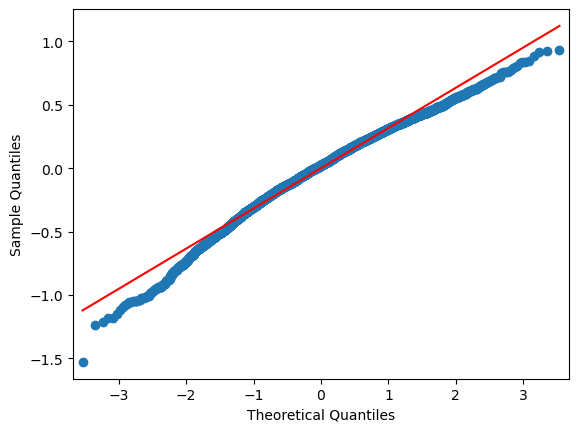

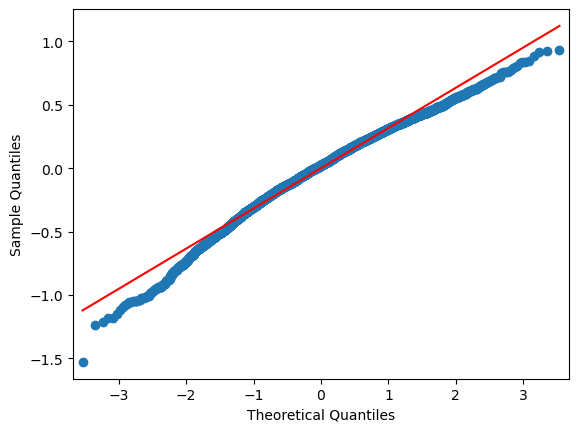

In [39]:
sm.qqplot(residuals, line='s')

**Independence**

Based on the ACF graph, the bars after lag 0 appear to be close to 0 indicating the independence assumption being satisfied.

(-0.1, 1.1)

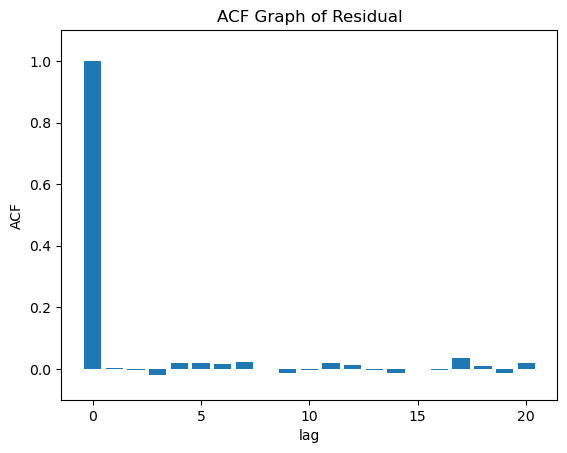

In [40]:
lags = 20
plt.bar(range(lags+1), acf(residuals, nlags=lags))
plt.title("ACF Graph of Residual")
plt.xlabel('lag')
plt.ylabel('ACF')
plt.ylim((-0.1, 1.1))

**Heteroscedasticity**

Based on the scatterplot of standardized residuals vs. fitted values, we see that there is a lot of scattered points around 0 indicating that the heteroscedasticity assumption is satisfied. We also see that the scatter plot is random indicating the linearity assumption being satisfied.

Text(0.5, 0, 'Fitted Values')

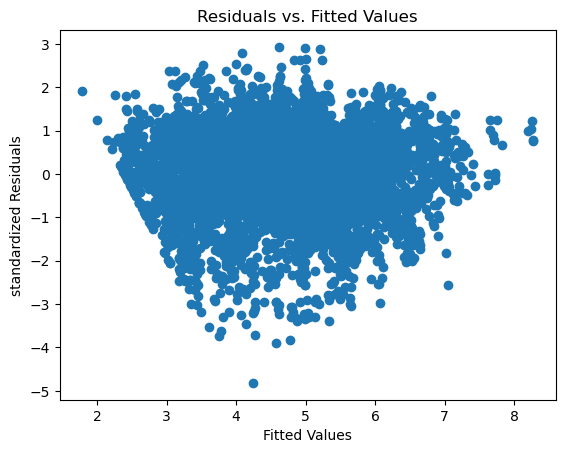

In [41]:
def standardize(X):
    return (X - X.mean()) / X.std()

plt.scatter(death_model.fittedvalues, standardize(residuals))
plt.title("Residuals vs. Fitted Values")
plt.ylabel("standardized Residuals")
plt.xlabel("Fitted Values")

##### Test Accuracy On Test Set

These are the log scaled metrics as the targets have been log scaled

In [42]:
def validate_model(model,test_df,target):
    targets = test_df[target]
    preds = model.predict(exog=test_df)
    mae = metrics.mean_absolute_error(targets, preds)
    mse = metrics.mean_squared_error(targets, preds)
    rmse = np.sqrt(mse) 
    r_squared = metrics.r2_score(targets, preds)
    print(f"Test Set MAE: {mae:.2f}")
    print(f"Test Set RMSE: {rmse:.2f}")
    print(f"Test Set R-squared: {r_squared:.2f}")

In [43]:
validate_model(death_model,test_df,"Deaths")

Test Set MAE: 0.25
Test Set RMSE: 0.32
Test Set R-squared: 0.92


##### Model Performance on Test Data
To evaluate the predictive performance of the regression model, we applied it to the test dataset. The model achieved a test MAE of 0.25 and a test RMSE of 0.32, indicating that the average prediction error is relatively small. 

In addition, the model obtained a test $R^2$ of 0.92, suggesting that it explains approximately 92% of the variation in respiratory disease deaths in the test data.

These results indicate that the model maintains strong predictive performance on unseen data, suggesting that the selected predictors generalize well beyond the training dataset.

### Mutliple Linear Regeression Model For Crude Rate

##### BIC Model Selection

In [44]:
formulas = generate_formulas("Crude_Rate", in_features)
selected_model = find_best_bic(formulas)
print(f"Selected Model: {selected_model}")

  0%|          | 0/262143 [00:00<?, ?it/s]

Selected Model: Crude_Rate~Year + Moderate_Days + Max_AQI + Population + Unhealthy_Days_binary + Very_Unhealthy_Days_binary + Days_NO2_binary


In [45]:
crude_model = smf.ols(formula=selected_model, data=train_df).fit()
crude_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:             Crude_Rate   R-squared:                       0.372
Model:                            OLS   Adj. R-squared:                  0.371
Method:                 Least Squares   F-statistic:                     417.7
Date:                Sat, 14 Mar 2026   Prob (F-statistic):               0.00
Time:                        20:30:13   Log-Likelihood:                -1355.9
No. Observations:                4939   AIC:                             2728.
Df Residuals:                    4931   BIC:                             2780.
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
==============================================================================================
                                 coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------
Intercept                     34.0309      4.591      7.412      0.000      25.030      43.032
Year                          -0.0134      0.002     -5.893      0.000      -0.018      -0.009
Moderate_Days                  0.0006   8.84e-05      7.256      0.000       0.000       0.001
Max_AQI                       -0.0971      0.017     -5.792      0.000      -0.130      -0.064
Population                    -0.1705      0.004    -42.372      0.000      -0.178      -0.163
Unhealthy_Days_binary         -0.0640      0.015     -4.137      0.000      -0.094      -0.034
Very_Unhealthy_Days_binary     0.0871      0.023      3.778      0.000       0.042       0.132
Days_NO2_binary               -0.1248      0.013     -9.431      0.000      -0.151      -0.099
==============================================================================
Omnibus:                      231.164   Durbin-Watson:                   1.994
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              272.511
Skew:                          -0.517   Prob(JB):                     6.68e-60
Kurtosis:                       3.504   Cond. No.                     2.05e+06
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 2.05e+06. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

##### Interpretation of Regression Results 

The results for the crude rate model are largely consistent with those observed in the death model. Variables such as *Moderate_Days* and *Very_Unhealthy_Days_binary* remain positively associated with respiratory mortality, suggesting that higher levels of air pollution are linked to worse respiratory health outcomes. Similarly, *Year* continues to show a negative coefficient, indicating a slight decreasing trend in respiratory mortality over time.

One notable difference is the coefficient for *Population*, which is negative in this model. This is expected because the crude rate measures deaths relative to population size, meaning that areas with larger populations may have lower mortality rates when deaths are normalized by population.

Overall, the model explains a moderate portion of the variation in crude rate, with an R² of 0.372. The F-statistic remains highly significant (p < 0.001), indicating that the predictors collectively provide a statistically meaningful explanation of the variation in the response variable.

##### Validate Model Assumptions

In [46]:
residuals = crude_model.resid

**Normality**

Residuals are approximately normally distributed with minor deviation in the tails, particularly at the lower extreme likely driven by counties with very low death counts. Based on the mild deviation from the line, our model doesn't materially violate the normality assumption.

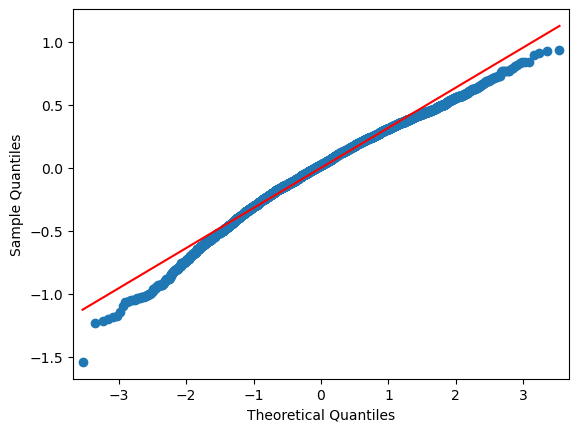

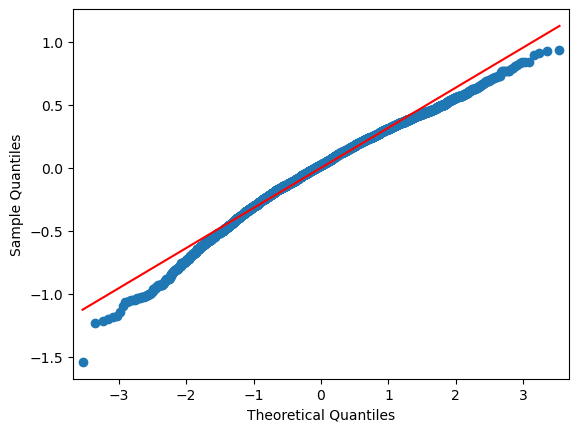

In [47]:
sm.qqplot(residuals, line='s')

**Independence**

Based on the ACF graph, the bars after lag 0 appear to be close to 0 indicating the independence assumption being satisfied.

(-0.1, 1.1)

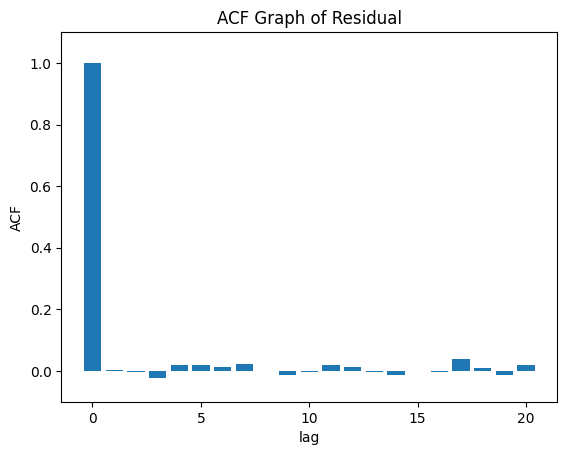

In [41]:
lags = 20
plt.bar(range(lags+1), acf(residuals, nlags=lags))
plt.title("ACF Graph of Residual")
plt.xlabel('lag')
plt.ylabel('ACF')
plt.ylim((-0.1, 1.1))

**Heteroscedasticity**

Based on the scatterplot of standardized residuals vs. fitted values, we see that there is a lot of scattered points around 0 indicating that the heteroscedasticity assumption is satisfied. We also see that the scatter plot is random indicating the linearity assumption being satisfied.

Text(0.5, 0, 'Fitted Values')

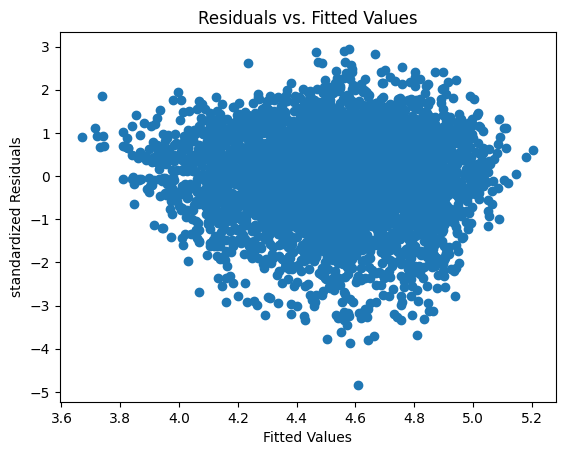

In [42]:
plt.scatter(crude_model.fittedvalues, standardize(residuals))
plt.title("Residuals vs. Fitted Values")
plt.ylabel("standardized Residuals")
plt.xlabel("Fitted Values")

##### Test Accuracy On Test Set

These are the log scaled metrics as the targets have been log scaled

In [43]:
def validate_model(model,test_df,target):
    targets = test_df[target]
    preds = model.predict(exog=test_df)
    mae = metrics.mean_absolute_error(targets, preds)
    mse = metrics.mean_squared_error(targets, preds)
    rmse = np.sqrt(mse) 
    r_squared = metrics.r2_score(targets, preds)
    print(f"Test Set MAE: {mae:.2f}")
    print(f"Test Set RMSE: {rmse:.2f}")
    print(f"Test Set R-squared: {r_squared:.2f}")

In [44]:
validate_model(crude_model,test_df,"Crude_Rate")

Test Set MAE: 0.25
Test Set RMSE: 0.32
Test Set R-squared: 0.39


##### Model Performance on Test Data
To evaluate the predictive performance of the model, we applied it to the test dataset. The model achieved a test MAE of 0.25 and a test RMSE of 0.32, indicating that the prediction errors are relatively small on average. The test $R^2$ is 0.39, meaning that the model explains about 39% of the variation in Crude_Rate in the test data.

Although the $R^2$ is lower than that of the Deaths model, this is expected because Crude_Rate represents deaths relative to population size, which removes much of the variation explained by population. Additionally, the crude rate may depend on other factors not included in the model, so the predictors capture only part of the variation in the response variable.